# Phân Loại Cảm Xúc Sử Dụng Random Forest

Dự án này sử dụng mô hình Random Forest để phân loại cảm xúc từ dữ liệu văn bản (Comment).

## 1. Import Thư Viện Cần Thiết

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import re
import warnings
warnings.filterwarnings('ignore')

# Cấu hình matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

## 2. Load và Khám Phá Dữ Liệu

In [56]:
# Load dữ liệu
df = pd.read_csv('sentiment_data.csv')

# Hiển thị thông tin cơ bản
print("=" * 80)
print("THÔNG TIN DỮ LIỆU TẢI VỀ")
print("=" * 80)
print(f"\nKích thước dữ liệu: {df.shape}")
print(f"\nCác cột: {df.columns.tolist()}")
print(f"\nKiểu dữ liệu:\n{df.dtypes}")
print(f"\nGiá trị thiếu:\n{df.isnull().sum()}")
print(f"\n5 dòng đầu tiên:")
print(df.head())

THÔNG TIN DỮ LIỆU TẢI VỀ

Kích thước dữ liệu: (241145, 3)

Các cột: ['Unnamed: 0', 'Comment', 'Sentiment']

Kiểu dữ liệu:
Unnamed: 0     int64
Comment       object
Sentiment      int64
dtype: object

Giá trị thiếu:
Unnamed: 0      0
Comment       217
Sentiment       0
dtype: int64

5 dòng đầu tiên:
   Unnamed: 0  \
0           0   
1           1   
2           2   
3           3   
4           4   

                                                                                                                                                                                                                                                                                                                                    Comment  \
0                                                                                                   lets forget apple pay required brand new iphone order use significant portion apples user base wasnt able use even wanted successive iphone incorporated technolog

In [57]:
# Thống kê cảm xúc
print("\n" + "=" * 80)
print("PHÂN BỐ CẢM XÚC")
print("=" * 80)
sentiment_counts = df['Sentiment'].value_counts().sort_index()
sentiment_map = {0: 'Tiêu cực (0)', 1: 'Trung tính (1)', 2: 'Tích cực (2)'}
print("\nSố lượng mẫu theo cảm xúc:")
for idx, count in sentiment_counts.items():
    print(f"  {sentiment_map.get(idx, f'Cảm xúc {idx}')}: {count} mẫu ({count/len(df)*100:.2f}%)")

# Loại bỏ các dòng có Comment rỗng hoặc NaN
df = df.dropna(subset=['Comment'])
df = df[df['Comment'].str.strip() != ''].reset_index(drop=True)

print(f"\nSố dòng sau loại bỏ dữ liệu rỗng: {len(df)}")

# Kiểm tra độ dài comment
df['comment_length'] = df['Comment'].apply(len)
print(f"\nThống kê độ dài Comment:")
print(f"  Trung bình: {df['comment_length'].mean():.2f} ký tự")
print(f"  Trung vị: {df['comment_length'].median():.2f} ký tự")
print(f"  Min: {df['comment_length'].min()} ký tự")
print(f"  Max: {df['comment_length'].max()} ký tự")


PHÂN BỐ CẢM XÚC

Số lượng mẫu theo cảm xúc:
  Tiêu cực (0): 55114 mẫu (22.86%)
  Trung tính (1): 82972 mẫu (34.41%)
  Tích cực (2): 103059 mẫu (42.74%)

Số dòng sau loại bỏ dữ liệu rỗng: 240928

Thống kê độ dài Comment:
  Trung bình: 87.66 ký tự
  Trung vị: 72.00 ký tự
  Min: 1 ký tự
  Max: 5080 ký tự


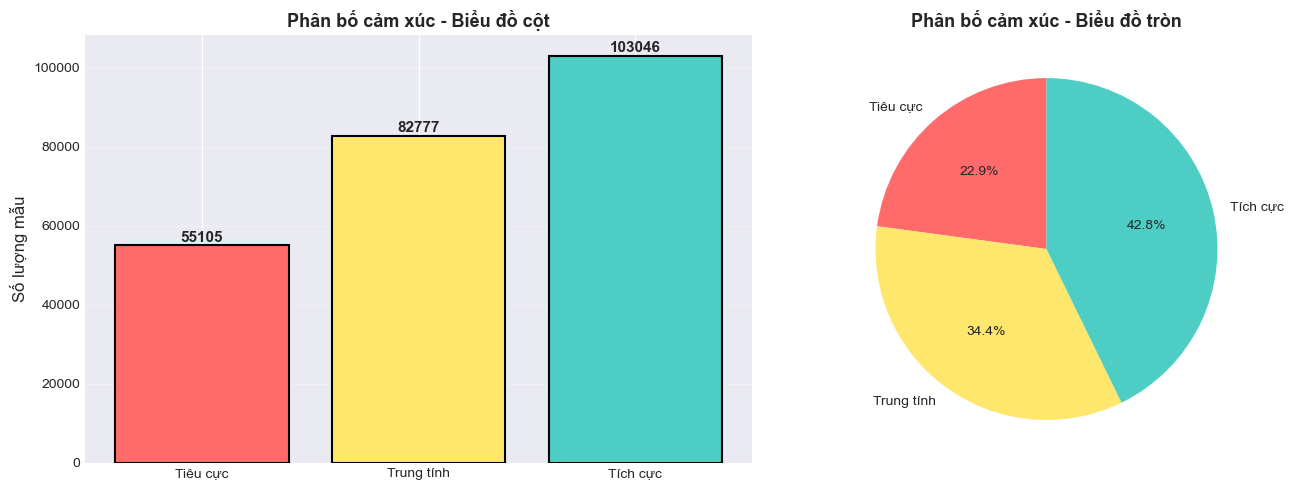

✓ Biểu đồ phân bố cảm xúc đã được lưu


In [58]:
# Biểu đồ phân bố cảm xúc
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ cột
sentiment_names = ['Tiêu cực', 'Trung tính', 'Tích cực']
sentiment_counts_list = df['Sentiment'].value_counts().sort_index().values
axes[0].bar(sentiment_names, sentiment_counts_list, color=['#FF6B6B', '#FFE66D', '#4ECDC4'], edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Số lượng mẫu', fontsize=12)
axes[0].set_title('Phân bố cảm xúc - Biểu đồ cột', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(sentiment_counts_list):
    axes[0].text(i, v + 100, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')

# Biểu đồ tròn
colors = ['#FF6B6B', '#FFE66D', '#4ECDC4']
axes[1].pie(sentiment_counts_list, labels=sentiment_names, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Phân bố cảm xúc - Biểu đồ tròn', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Biểu đồ phân bố cảm xúc đã được lưu")

## 3. Tiền Xử Lý Dữ Liệu Văn Bản

In [59]:
# Hàm tiền xử lý văn bản
def clean_text(text):
    """
    Làm sạch và tiền xử lý văn bản
    """
    if isinstance(text, float):
        return ""
    
    # Chuyển thành chữ thường
    text = text.lower()
    
    # Loại bỏ URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Loại bỏ email
    text = re.sub(r'\S+@\S+', '', text)
    
    # Loại bỏ ký tự đặc biệt và số
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Loại bỏ khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Áp dụng tiền xử lý
print("Tiền xử lý dữ liệu văn bản...")
df['Comment_cleaned'] = df['Comment'].apply(clean_text)

# Loại bỏ các comment rỗng sau tiền xử lý
df = df[df['Comment_cleaned'].str.len() > 0].reset_index(drop=True)

print(f"Số dòng sau tiền xử lý: {len(df)}")
print(f"\nVí dụ comment ban đầu vs comment đã xử lý:")
print("-" * 100)
for i in range(3):
    print(f"\nBan đầu:   {df['Comment'].iloc[i][:100]}...")
    print(f"Đã xử lý:   {df['Comment_cleaned'].iloc[i][:100]}...")
    print(f"Cảm xúc:    {sentiment_map.get(df['Sentiment'].iloc[i])}")

Tiền xử lý dữ liệu văn bản...
Số dòng sau tiền xử lý: 240661

Ví dụ comment ban đầu vs comment đã xử lý:
----------------------------------------------------------------------------------------------------

Ban đầu:   lets forget apple pay required brand new iphone order use significant portion apples user base wasnt...
Đã xử lý:   lets forget apple pay required brand new iphone order use significant portion apples user base wasnt...
Cảm xúc:    Trung tính (1)

Ban đầu:   nz retailers don’t even contactless credit card machines like paywave support apple pay don’t like h...
Đã xử lý:   nz retailers dont even contactless credit card machines like paywave support apple pay dont like hig...
Cảm xúc:    Tiêu cực (0)

Ban đầu:   forever acknowledge channel help lessons ideas explanations quite helpful youll sit comfort monitor ...
Đã xử lý:   forever acknowledge channel help lessons ideas explanations quite helpful youll sit comfort monitor ...
Cảm xúc:    Tích cực (2)
Số dòng sau tiền xử l

## 4. Trích Xuất Đặc Trưng Từ Văn Bản

In [60]:
print("\n" + "=" * 80)
print("TRÍCH XUẤT ĐẶC TRƯNG SỬ DỤNG TF-IDF")
print("=" * 80)

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=3000,      # Số lượng đặc trưng tối đa
    min_df=5,               # Tối thiểu 5 tài liệu chứa từ
    max_df=0.8,             # Tối đa 80% tài liệu chứa từ
    ngram_range=(1, 2),     # Sử dụng unigram và bigram  
    strip_accents='unicode'
)

# Fit và transform dữ liệu
X = tfidf.fit_transform(df['Comment_cleaned'])
y = df['Sentiment']

print(f"\nMa trận đặc trưng:")
print(f"  Kích thước: {X.shape}")
print(f"  Số đặc trưng: {X.shape[1]}")
print(f"  Loại dữ liệu: Ma trận thưa (Sparse Matrix)")
print(f"  Số phần tử khác 0: {X.nnz}")
print(f"  Mật độ: {X.nnz / (X.shape[0] * X.shape[1]) * 100:.4f}%")

# Lấy tên đặc trưng (từ)
feature_names = np.array(tfidf.get_feature_names_out())
print(f"\nTop 20 đặc trưng quan trọng nhất (theo độ tần suất):")
print("-" * 60)
mean_tf_idf = np.array(X.mean(axis=0)).flatten()
top_indices = np.argsort(mean_tf_idf)[-20:][::-1]
for idx, feature_idx in enumerate(top_indices, 1):
    print(f"  {idx:2d}. {feature_names[feature_idx]:20s} - Trung bình TF-IDF: {mean_tf_idf[feature_idx]:.6f}")


TRÍCH XUẤT ĐẶC TRƯNG SỬ DỤNG TF-IDF

Ma trận đặc trưng:
  Kích thước: (240661, 3000)
  Số đặc trưng: 3000
  Loại dữ liệu: Ma trận thưa (Sparse Matrix)
  Số phần tử khác 0: 2332333
  Mật độ: 0.3230%

Top 20 đặc trưng quan trọng nhất (theo độ tần suất):
------------------------------------------------------------
   1. modi                 - Trung bình TF-IDF: 0.057097
   2. india                - Trung bình TF-IDF: 0.018098
   3. like                 - Trung bình TF-IDF: 0.013906
   4. people               - Trung bình TF-IDF: 0.011260
   5. one                  - Trung bình TF-IDF: 0.010992
   6. bjp                  - Trung bình TF-IDF: 0.010640
   7. good                 - Trung bình TF-IDF: 0.010246
   8. dont                 - Trung bình TF-IDF: 0.009798
   9. narendra             - Trung bình TF-IDF: 0.009783
  10. time                 - Trung bình TF-IDF: 0.009545
  11. congress             - Trung bình TF-IDF: 0.009389
  12. im                   - Trung bình TF-IDF: 0.009093
  

## 5. Chia Dữ Liệu Thành Train/Test Sets

In [61]:
print("\n" + "=" * 80)
print("CHIA DỮ LIỆU THÀNH TRAIN/TEST SETS")
print("=" * 80)

# Chia dữ liệu: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

print(f"\nThống kê chia dữ liệu:")
print(f"  Tổng số mẫu: {len(df)}")
print(f"  Tập huấn luyện: {X_train.shape[0]} mẫu ({X_train.shape[0]/len(df)*100:.2f}%)")
print(f"  Tập kiểm tra: {X_test.shape[0]} mẫu ({X_test.shape[0]/len(df)*100:.2f}%)")

print(f"\nPhân bố cảm xúc trong tập huấn luyện:")
for sentiment_id in sorted(y_train.unique()):
    count = (y_train == sentiment_id).sum()
    print(f"  {sentiment_map.get(sentiment_id)}: {count} mẫu ({count/len(y_train)*100:.2f}%)")

print(f"\nPhân bố cảm xúc trong tập kiểm tra:")
for sentiment_id in sorted(y_test.unique()):
    count = (y_test == sentiment_id).sum()
    print(f"  {sentiment_map.get(sentiment_id)}: {count} mẫu ({count/len(y_test)*100:.2f}%)")


CHIA DỮ LIỆU THÀNH TRAIN/TEST SETS

Thống kê chia dữ liệu:
  Tổng số mẫu: 240661
  Tập huấn luyện: 192528 mẫu (80.00%)
  Tập kiểm tra: 48133 mẫu (20.00%)

Phân bố cảm xúc trong tập huấn luyện:
  Tiêu cực (0): 44077 mẫu (22.89%)
  Trung tính (1): 66045 mẫu (34.30%)
  Tích cực (2): 82406 mẫu (42.80%)

Phân bố cảm xúc trong tập kiểm tra:
  Tiêu cực (0): 11019 mẫu (22.89%)
  Trung tính (1): 16512 mẫu (34.30%)
  Tích cực (2): 20602 mẫu (42.80%)


## 6. Huấn Luyện Mô Hình SVM (Mô Hình Chính)

In [97]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

print("\n" + "=" * 80)
print("HUẤN LUYỆN MÔ HÌNH SVM (MÔ HÌNH CHÍNH)")
print("=" * 80)

# ============= SVM (Linear SVC) - MÔ HÌNH CHÍNH =============
print("\n🚀 Huấn luyện SVM (Linear SVC)...")
svm_model = LinearSVC(max_iter=2000, random_state=42, verbose=0, class_weight='balanced')
svm_model.fit(X_train, y_train)
print("✓ Hoàn thành huấn luyện SVM!")

# Dự đoán với SVM
svm_train_pred = svm_model.predict(X_train)
svm_test_pred = svm_model.predict(X_test)
svm_train_accuracy = accuracy_score(y_train, svm_train_pred)
svm_test_accuracy = accuracy_score(y_test, svm_test_pred)

print(f"\nSVM (Linear SVC) - Độ chính xác:")
print(f"  Train: {svm_train_accuracy:.6f} ({svm_train_accuracy*100:.2f}%)")
print(f"  Test:  {svm_test_accuracy:.6f} ({svm_test_accuracy*100:.2f}%)")



HUẤN LUYỆN MÔ HÌNH SVM (MÔ HÌNH CHÍNH)

🚀 Huấn luyện SVM (Linear SVC)...
✓ Hoàn thành huấn luyện SVM!

SVM (Linear SVC) - Độ chính xác:
  Train: 0.777960 (77.80%)
  Test:  0.768475 (76.85%)
✓ Hoàn thành huấn luyện SVM!

SVM (Linear SVC) - Độ chính xác:
  Train: 0.777960 (77.80%)
  Test:  0.768475 (76.85%)


In [98]:
print("\n" + "=" * 80)
print("ĐÁNH GIÁ CHI TIẾT - SVM (MÔ HÌNH CHÍNH)")
print("=" * 80)
print("\n" + classification_report(y_test, svm_test_pred, 
                           target_names=[sentiment_map.get(i) for i in sorted(np.unique(y_test))],
                           digits=4))



ĐÁNH GIÁ CHI TIẾT - SVM (MÔ HÌNH CHÍNH)

                precision    recall  f1-score   support

  Tiêu cực (0)     0.7275    0.6624    0.6934     11019
Trung tính (1)     0.7158    0.8302    0.7688     16512
  Tích cực (2)     0.8434    0.7757    0.8082     20602

      accuracy                         0.7685     48133
     macro avg     0.7622    0.7561    0.7568     48133
  weighted avg     0.7731    0.7685    0.7684     48133



## 6b. Huấn Luyện Mô Hình Naive Bayes và Random Forest

In [99]:
print("\n" + "=" * 80)
print("HUẤN LUYỆN MÔ HÌNH NAIVE BAYES VÀ RANDOM FOREST")
print("=" * 80)

# ============= NAIVE BAYES =============
print("\n📚 Huấn luyện Naive Bayes...")
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train, y_train)
print("✓ Hoàn thành huấn luyện Naive Bayes!")

# Dự đoán với Naive Bayes
nb_train_pred = nb_model.predict(X_train)
nb_test_pred = nb_model.predict(X_test)
nb_train_accuracy = accuracy_score(y_train, nb_train_pred)
nb_test_accuracy = accuracy_score(y_test, nb_test_pred)

print(f"\nNaive Bayes - Độ chính xác:")
print(f"  Train: {nb_train_accuracy:.6f} ({nb_train_accuracy*100:.2f}%)")
print(f"  Test:  {nb_test_accuracy:.6f} ({nb_test_accuracy*100:.2f}%)")

# ============= RANDOM FOREST =============
print("\n🌳 Huấn luyện Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=200,           # Số cây quyết định
    max_depth=12,               # Độ sâu tối đa của mỗi cây
    min_samples_split=5,        # Số mẫu tối thiểu để chia nút
    min_samples_leaf=2,         # Số mẫu tối thiểu tại lá
    max_features='sqrt',        # Số đặc trưng để xem xét tại mỗi nút
    random_state=42,
    n_jobs=-1,                  # Sử dụng tất cả CPU cores
    class_weight='balanced',    # Cân bằng trọng số cho các lớp
    oob_score=True              # Tính Out-of-Bag score
)

print("\nThông số Random Forest:")
print(f"  Số cây (n_estimators): {rf_model.n_estimators}")
print(f"  Độ sâu tối đa (max_depth): {rf_model.max_depth}")
print(f"  Min samples split: {rf_model.min_samples_split}")
print(f"  Min samples leaf: {rf_model.min_samples_leaf}")
print(f"  Max features: {rf_model.max_features}")

print("\nBắt đầu huấn luyện Random Forest...")
rf_model.fit(X_train, y_train)
print("✓ Hoàn thành huấn luyện Random Forest!")

# Dự đoán với Random Forest
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)
rf_train_accuracy = accuracy_score(y_train, rf_train_pred)
rf_test_accuracy = accuracy_score(y_test, rf_test_pred)
oob_score = rf_model.oob_score_

print(f"\nRandom Forest - Độ chính xác:")
print(f"  Train: {rf_train_accuracy:.6f} ({rf_train_accuracy*100:.2f}%)")
print(f"  Test:  {rf_test_accuracy:.6f} ({rf_test_accuracy*100:.2f}%)")
print(f"  OOB Score: {oob_score:.6f} ({oob_score*100:.2f}%)")



HUẤN LUYỆN MÔ HÌNH NAIVE BAYES VÀ RANDOM FOREST

📚 Huấn luyện Naive Bayes...
✓ Hoàn thành huấn luyện Naive Bayes!

Naive Bayes - Độ chính xác:
  Train: 0.676380 (67.64%)
  Test:  0.664077 (66.41%)

🌳 Huấn luyện Random Forest...

Thông số Random Forest:
  Số cây (n_estimators): 200
  Độ sâu tối đa (max_depth): 12
  Min samples split: 5
  Min samples leaf: 2
  Max features: sqrt

Bắt đầu huấn luyện Random Forest...
✓ Hoàn thành huấn luyện Random Forest!
✓ Hoàn thành huấn luyện Random Forest!

Random Forest - Độ chính xác:
  Train: 0.669149 (66.91%)
  Test:  0.665718 (66.57%)
  OOB Score: 0.656928 (65.69%)

Random Forest - Độ chính xác:
  Train: 0.669149 (66.91%)
  Test:  0.665718 (66.57%)
  OOB Score: 0.656928 (65.69%)



ĐÁNH GIÁ CHI TIẾT - NAIVE BAYES

                precision    recall  f1-score   support

  Tiêu cực (0)     0.7654    0.4325    0.5527     11019
Trung tính (1)     0.6492    0.6197    0.6341     16512
  Tích cực (2)     0.6489    0.8235    0.7259     20602

      accuracy                         0.6641     48133
     macro avg     0.6878    0.6252    0.6376     48133
  weighted avg     0.6757    0.6641    0.6547     48133


ĐÁNH GIÁ CHI TIẾT - RANDOM FOREST

                precision    recall  f1-score   support

  Tiêu cực (0)     0.6802    0.4970    0.5743     11019
Trung tính (1)     0.5627    0.8659    0.6821     16512
  Tích cực (2)     0.8363    0.5956    0.6957     20602

      accuracy                         0.6657     48133
     macro avg     0.6930    0.6528    0.6507     48133
  weighted avg     0.7067    0.6657    0.6632     48133


MA TRẬN NHẦM LẪN - SO SÁNH CÁ MÔ HÌNH


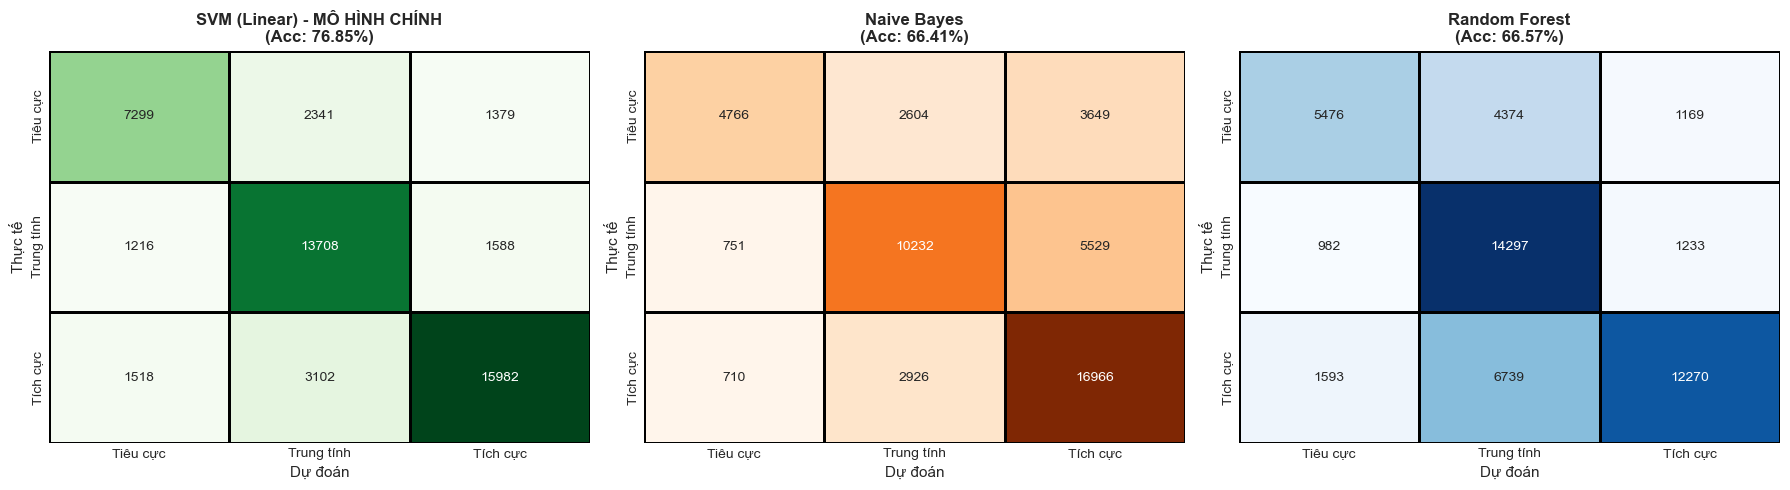


✓ Biểu đồ ma trận nhầm lẫn đã được lưu


In [100]:

print("\n" + "=" * 80)
print("ĐÁNH GIÁ CHI TIẾT - NAIVE BAYES")
print("=" * 80)
print("\n" + classification_report(y_test, nb_test_pred, 
                           target_names=[sentiment_map.get(i) for i in sorted(np.unique(y_test))],
                           digits=4))

print("\n" + "=" * 80)
print("ĐÁNH GIÁ CHI TIẾT - RANDOM FOREST")
print("=" * 80)
print("\n" + classification_report(y_test, rf_test_pred, 
                           target_names=[sentiment_map.get(i) for i in sorted(np.unique(y_test))],
                           digits=4))

# So sánh confusion matrix của cả 3 mô hình
print("\n" + "=" * 80)
print("MA TRẬN NHẦM LẪN - SO SÁNH CÁ MÔ HÌNH")
print("=" * 80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix - SVM (Mô hình chính)
cm_svm = confusion_matrix(y_test, svm_test_pred)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Tiêu cực', 'Trung tính', 'Tích cực'],
            yticklabels=['Tiêu cực', 'Trung tính', 'Tích cực'],
            cbar=False, ax=axes[0], linewidths=1, linecolor='black')
axes[0].set_title('SVM (Linear) - MÔ HÌNH CHÍNH\n(Acc: {:.2%})'.format(svm_test_accuracy), fontsize=12, fontweight='bold')
axes[0].set_xlabel('Dự đoán', fontsize=11)
axes[0].set_ylabel('Thực tế', fontsize=11)

# Confusion Matrix - Naive Bayes
cm_nb = confusion_matrix(y_test, nb_test_pred)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Tiêu cực', 'Trung tính', 'Tích cực'],
            yticklabels=['Tiêu cực', 'Trung tính', 'Tích cực'],
            cbar=False, ax=axes[1], linewidths=1, linecolor='black')
axes[1].set_title('Naive Bayes\n(Acc: {:.2%})'.format(nb_test_accuracy), fontsize=12, fontweight='bold')
axes[1].set_xlabel('Dự đoán', fontsize=11)
axes[1].set_ylabel('Thực tế', fontsize=11)

# Confusion Matrix - Random Forest
cm_rf = confusion_matrix(y_test, rf_test_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Tiêu cực', 'Trung tính', 'Tích cực'],
            yticklabels=['Tiêu cực', 'Trung tính', 'Tích cực'],
            cbar=False, ax=axes[2], linewidths=1, linecolor='black')
axes[2].set_title('Random Forest\n(Acc: {:.2%})'.format(rf_test_accuracy), fontsize=12, fontweight='bold')
axes[2].set_xlabel('Dự đoán', fontsize=11)
axes[2].set_ylabel('Thực tế', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Biểu đồ ma trận nhầm lẫn đã được lưu")


In [101]:
import joblib

print("\n" + "=" * 80)
print("LƯU CÁC MÔ HÌNH")
print("=" * 80)

# Lưu SVM (Mô hình chính)
joblib.dump(svm_model, 'sentiment_svm_model.pkl')
print("\n✓ Mô hình SVM (Linear SVC) đã được lưu: sentiment_svm_model.pkl")

# Lưu Naive Bayes
joblib.dump(nb_model, 'sentiment_nb_model.pkl')
print("✓ Mô hình Naive Bayes đã được lưu: sentiment_nb_model.pkl")

# Lưu Random Forest
joblib.dump(rf_model, 'sentiment_rf_model.pkl')
print("✓ Mô hình Random Forest đã được lưu: sentiment_rf_model.pkl")

# Lưu TF-IDF Vectorizer
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
print("✓ TF-IDF Vectorizer đã được lưu: tfidf_vectorizer.pkl")

print("\nBạn có thể tải lại các mô hình bằng:")
print("  svm_model = joblib.load('sentiment_svm_model.pkl')    # Mô hình chính")
print("  nb_model = joblib.load('sentiment_nb_model.pkl')")
print("  rf_model = joblib.load('sentiment_rf_model.pkl')")
print("  tfidf = joblib.load('tfidf_vectorizer.pkl')")



LƯU CÁC MÔ HÌNH

✓ Mô hình SVM (Linear SVC) đã được lưu: sentiment_svm_model.pkl
✓ Mô hình Naive Bayes đã được lưu: sentiment_nb_model.pkl
✓ Mô hình Random Forest đã được lưu: sentiment_rf_model.pkl
✓ TF-IDF Vectorizer đã được lưu: tfidf_vectorizer.pkl

Bạn có thể tải lại các mô hình bằng:
  svm_model = joblib.load('sentiment_svm_model.pkl')    # Mô hình chính
  nb_model = joblib.load('sentiment_nb_model.pkl')
  rf_model = joblib.load('sentiment_rf_model.pkl')
  tfidf = joblib.load('tfidf_vectorizer.pkl')


## 7. Đánh Giá Hiệu Suất Mô Hình

In [79]:
print("\n" + "=" * 80)
print("ĐÁNH GIÁ HIỆU SUẤT MÔ HÌNH - SVM (MÔ HÌNH CHÍNH)")
print("=" * 80)

# Tính độ chính xác
print(f"\n📊 ĐỘ CHÍNH XÁC")
print("-" * 80)
print(f"Độ chính xác trên tập Train: {svm_train_accuracy:.6f} ({svm_train_accuracy*100:.2f}%)")
print(f"Độ chính xác trên tập Test:  {svm_test_accuracy:.6f} ({svm_test_accuracy*100:.2f}%)")

# Chi tiết cho từng cảm xúc
print(f"\n📈 CHI TIẾT ĐÁNH GIÁ THEO CẢM XÚC")
print("-" * 80)
print("\nTrên tập Test:")
print(f"{'Cảm xúc':<20} {'Precision':>12} {'Recall':>12} {'F1-Score':>12}")
print("-" * 60)

for sentiment_id in sorted(np.unique(y_test)):
    precision = precision_score(y_test, svm_test_pred, labels=[sentiment_id], average=None, zero_division=0)[0]
    recall = recall_score(y_test, svm_test_pred, labels=[sentiment_id], average=None, zero_division=0)[0]
    f1 = f1_score(y_test, svm_test_pred, labels=[sentiment_id], average=None, zero_division=0)[0]
    
    print(f"{sentiment_map.get(sentiment_id):<20} {precision:>12.4f} {recall:>12.4f} {f1:>12.4f}")

# Weighted average
precision_weighted = precision_score(y_test, svm_test_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_test, svm_test_pred, average='weighted', zero_division=0)
f1_weighted = f1_score(y_test, svm_test_pred, average='weighted', zero_division=0)
print("-" * 60)
print(f"{'Weighted Average':<20} {precision_weighted:>12.4f} {recall_weighted:>12.4f} {f1_weighted:>12.4f}")



ĐÁNH GIÁ HIỆU SUẤT MÔ HÌNH - SVM (MÔ HÌNH CHÍNH)

📊 ĐỘ CHÍNH XÁC
--------------------------------------------------------------------------------
Độ chính xác trên tập Train: 0.779777 (77.98%)
Độ chính xác trên tập Test:  0.768226 (76.82%)

📈 CHI TIẾT ĐÁNH GIÁ THEO CẢM XÚC
--------------------------------------------------------------------------------

Trên tập Test:
Cảm xúc                 Precision       Recall     F1-Score
------------------------------------------------------------
Tiêu cực (0)               0.7731       0.6088       0.6812
Trung tính (1)             0.7127       0.8309       0.7672
Tích cực (2)               0.8191       0.8033       0.8111
------------------------------------------------------------
Weighted Average           0.7720       0.7682       0.7663




BIỂU ĐỒ PRECISION, RECALL, F1-SCORE - SVM (MÔ HÌNH CHÍNH)


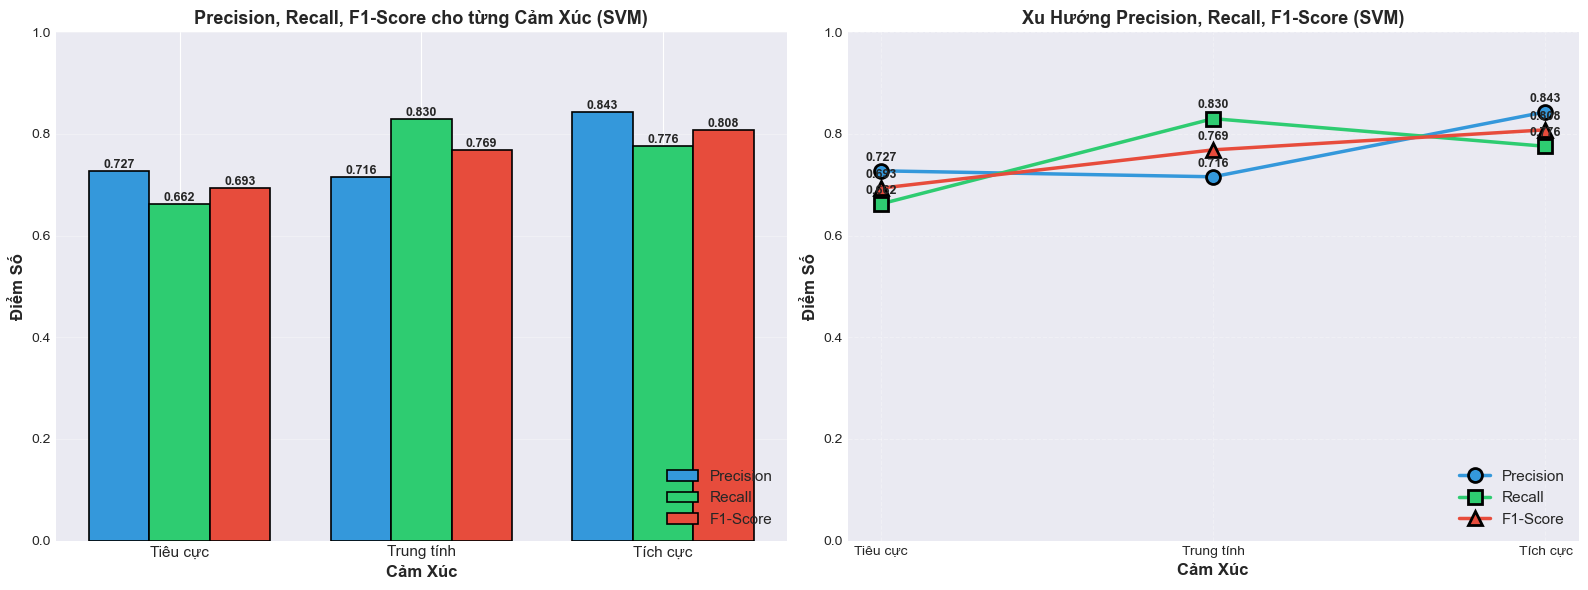


✓ Biểu đồ Precision, Recall, F1-Score của SVM đã được lưu


In [104]:

# Biểu đồ Precision, Recall, F1-Score của SVM
print("\n\n" + "=" * 80)
print("BIỂU ĐỒ PRECISION, RECALL, F1-SCORE - SVM (MÔ HÌNH CHÍNH)")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Dữ liệu cho biểu đồ 1: So sánh 3 chỉ số cho từng cảm xúc
sentiments = ['Tiêu cực', 'Trung tính', 'Tích cực']
precision_scores = []
recall_scores = []
f1_scores = []

for sentiment_id in sorted(np.unique(y_test)):
    precision = precision_score(y_test, svm_test_pred, labels=[sentiment_id], average=None, zero_division=0)[0]
    recall = recall_score(y_test, svm_test_pred, labels=[sentiment_id], average=None, zero_division=0)[0]
    f1 = f1_score(y_test, svm_test_pred, labels=[sentiment_id], average=None, zero_division=0)[0]
    
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

# Biểu đồ cột nhóm: So sánh Precision, Recall, F1 cho 3 cảm xúc
x = np.arange(len(sentiments))
width = 0.25

bars1 = axes[0].bar(x - width, precision_scores, width, label='Precision', color='#3498DB', edgecolor='black', linewidth=1.2)
bars2 = axes[0].bar(x, recall_scores, width, label='Recall', color='#2ECC71', edgecolor='black', linewidth=1.2)
bars3 = axes[0].bar(x + width, f1_scores, width, label='F1-Score', color='#E74C3C', edgecolor='black', linewidth=1.2)

axes[0].set_xlabel('Cảm Xúc', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Điểm Số', fontsize=12, fontweight='bold')
axes[0].set_title('Precision, Recall, F1-Score cho từng Cảm Xúc (SVM)', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(sentiments, fontsize=11)
axes[0].legend(fontsize=11, loc='lower right')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

# Thêm giá trị trên các cột
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# Biểu đồ 2: Đường so sánh 3 chỉ số
axes[1].plot(sentiments, precision_scores, marker='o', linewidth=2.5, markersize=10, 
             label='Precision', color='#3498DB', markerfacecolor='#3498DB', markeredgewidth=2, markeredgecolor='black')
axes[1].plot(sentiments, recall_scores, marker='s', linewidth=2.5, markersize=10,
             label='Recall', color='#2ECC71', markerfacecolor='#2ECC71', markeredgewidth=2, markeredgecolor='black')
axes[1].plot(sentiments, f1_scores, marker='^', linewidth=2.5, markersize=10,
             label='F1-Score', color='#E74C3C', markerfacecolor='#E74C3C', markeredgewidth=2, markeredgecolor='black')

axes[1].set_xlabel('Cảm Xúc', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Điểm Số', fontsize=12, fontweight='bold')
axes[1].set_title('Xu Hướng Precision, Recall, F1-Score (SVM)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11, loc='lower right')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3, linestyle='--')

# Thêm giá trị lên điểm
for i, sentiment in enumerate(sentiments):
    axes[1].text(i, precision_scores[i] + 0.02, f'{precision_scores[i]:.3f}', ha='center', fontsize=9, fontweight='bold')
    axes[1].text(i, recall_scores[i] + 0.02, f'{recall_scores[i]:.3f}', ha='center', fontsize=9, fontweight='bold')
    axes[1].text(i, f1_scores[i] + 0.02, f'{f1_scores[i]:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('svm_precision_recall_f1.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Biểu đồ Precision, Recall, F1-Score của SVM đã được lưu")


## 6c. So Sánh Các Mô Hình

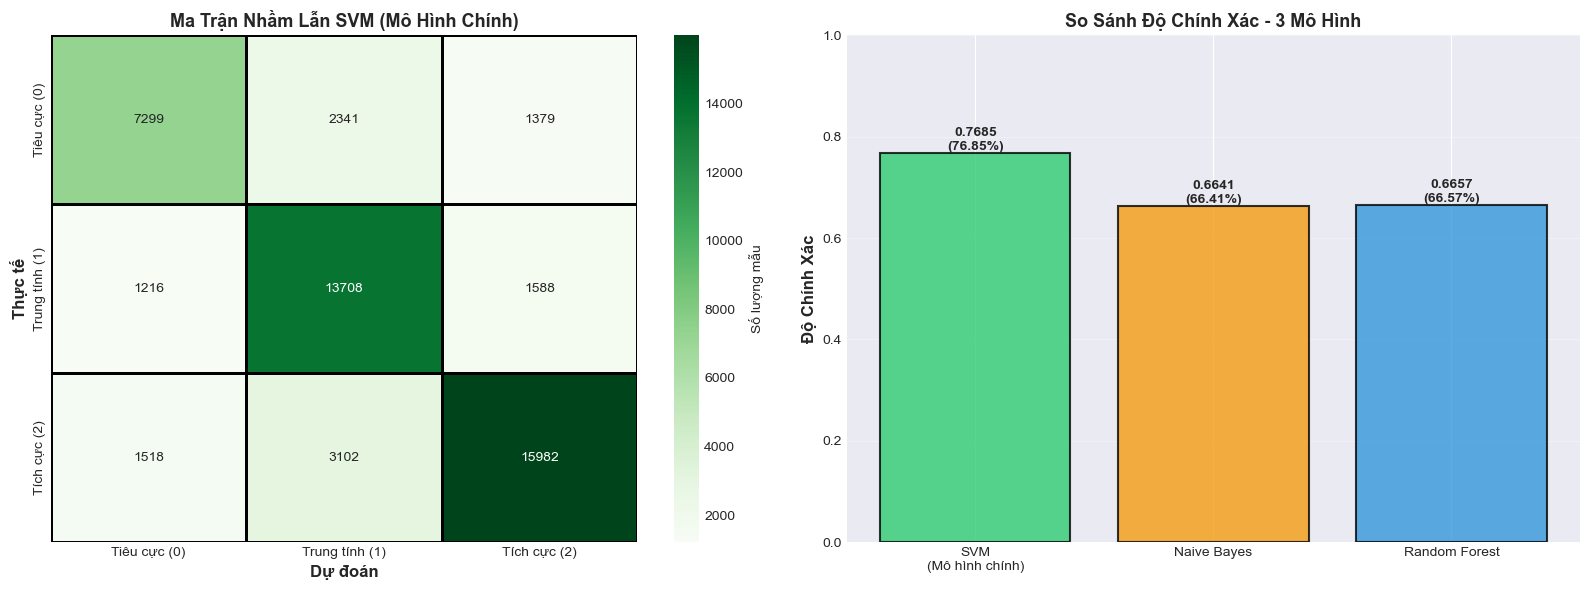


✓ Biểu đồ đánh giá đã được lưu


In [102]:
# Ma trận nhầm lẫn SVM
cm = confusion_matrix(y_test, svm_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix heatmap
sentiment_labels = ['Tiêu cực (0)', 'Trung tính (1)', 'Tích cực (2)']
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=sentiment_labels, yticklabels=sentiment_labels,
            cbar_kws={'label': 'Số lượng mẫu'}, ax=axes[0], linewidths=1, linecolor='black')
axes[0].set_xlabel('Dự đoán', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Thực tế', fontsize=12, fontweight='bold')
axes[0].set_title('Ma Trận Nhầm Lẫn SVM (Mô Hình Chính)', fontsize=13, fontweight='bold')

# Accuracy comparison - So sánh 3 mô hình
model_names = ['SVM\n(Mô hình chính)', 'Naive Bayes', 'Random Forest']
accuracies = [svm_test_accuracy, nb_test_accuracy, rf_test_accuracy]
colors_acc = ['#2ECC71', '#F39C12', '#3498DB']
bars = axes[1].bar(model_names, accuracies, color=colors_acc, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[1].set_ylabel('Độ Chính Xác', fontsize=12, fontweight='bold')
axes[1].set_title('So Sánh Độ Chính Xác - 3 Mô Hình', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

# Thêm giá trị lên trên các cột
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.4f}\n({acc*100:.2f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('sentiment_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Biểu đồ đánh giá đã được lưu")




TÍNH QUAN TRỌNG CỦA ĐẶC TRƯNG (Từ Random Forest)

Top 30 đặc trưng quan trọng nhất:
#     Đặc Trưng                        Độ Quan Trọng  Phần Trăm
-----------------------------------------------------------------
1     good                                  0.055615      5.56%
2     modi                                  0.053035      5.30%
3     hate                                  0.039364      3.94%
4     poor                                  0.036525      3.65%
5     best                                  0.035544      3.55%
6     love                                  0.035223      3.52%
7     great                                 0.033722      3.37%
8     fake                                  0.028651      2.87%
9     win                                   0.026845      2.68%
10    failed                                0.025984      2.60%
11    thanks                                0.023840      2.38%
12    proud                                 0.020568      2.06%
13    bad       

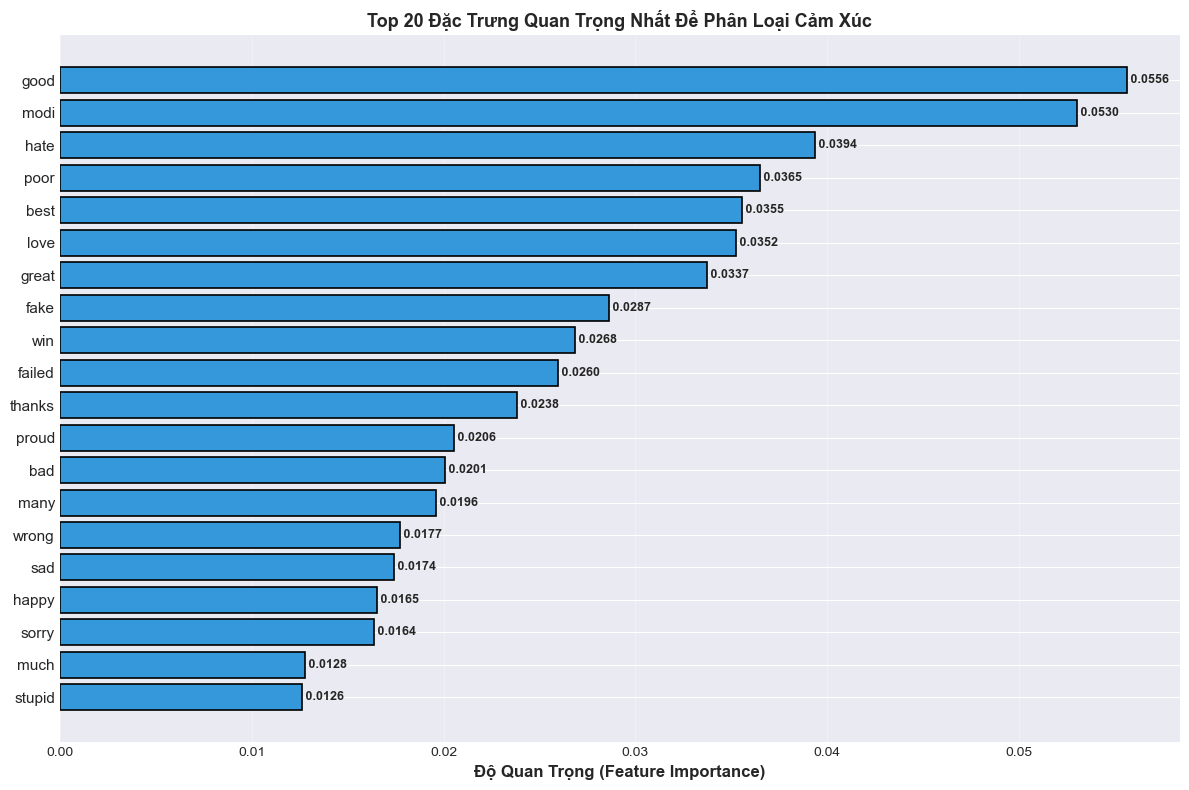


✓ Biểu đồ Feature Importance đã được lưu


In [69]:
# Feature Importance từ Random Forest
print("\n\n" + "=" * 80)
print("TÍNH QUAN TRỌNG CỦA ĐẶC TRƯNG (Từ Random Forest)")
print("=" * 80)

# Lấy feature importance
feature_importance = rf_model.feature_importances_
indices = np.argsort(feature_importance)[-30:][::-1]

print("\nTop 30 đặc trưng quan trọng nhất:")
print(f"{'#':<5} {'Đặc Trưng':<30} {'Độ Quan Trọng':>15} {'Phần Trăm':>10}")
print("-" * 65)
for rank, idx in enumerate(indices, 1):
    importance = feature_importance[idx]
    print(f"{rank:<5} {feature_names[idx]:<30} {importance:>15.6f} {importance*100:>9.2f}%")

# Visualize top 20 features
fig, ax = plt.subplots(figsize=(12, 8))
top_20_indices = indices[:20]
top_20_features = feature_names[top_20_indices]
top_20_importance = feature_importance[top_20_indices]

ax.barh(range(len(top_20_features)), top_20_importance, color='#3498DB', edgecolor='black', linewidth=1.2)
ax.set_yticks(range(len(top_20_features)))
ax.set_yticklabels(top_20_features, fontsize=11)
ax.set_xlabel('Độ Quan Trọng (Feature Importance)', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Đặc Trưng Quan Trọng Nhất Để Phân Loại Cảm Xúc', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Thêm giá trị
for i, v in enumerate(top_20_importance):
    ax.text(v, i, f' {v:.4f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Biểu đồ Feature Importance đã được lưu")


## 8. Dự Đoán Cảm Xúc Cho Dữ Liệu Mới

In [103]:
print("\n" + "=" * 80)
print("DỰ ĐOÁN CẢM XÚC CHO DỮ LIỆU MỚI (SỬ DỤNG SVM - MÔ HÌNH CHÍNH)")
print("=" * 80)

# Danh sách các comment mới để dự đoán
new_comments = [
    "This product is absolutely amazing! I love it!",
    "It's okay but nothing special",
    "Terrible quality and poor customer service",
    "Great value for money, highly recommended!",
    "Not satisfied with the purchase",
    "The best purchase I've ever made!",
    "Disappointed with the results",
    "It works as expected"
]

# Tiền xử lý các comment mới
new_comments_cleaned = [clean_text(comment) for comment in new_comments]

# Transform using TF-IDF
new_comments_tfidf = tfidf.transform(new_comments_cleaned)

# Dự đoán sử dụng SVM (mô hình chính)
predictions = svm_model.predict(new_comments_tfidf)

print("\nKết quả dự đoán cảm xúc (SVM):\n")
print(f"{'Comment':<50} {'Dự Đoán':<20}")
print("-" * 75)

for i, (comment, pred) in enumerate(zip(new_comments, predictions), 1):
    comment_short = comment[:47] + "..." if len(comment) > 50 else comment
    pred_sentiment = sentiment_map.get(pred)
    print(f"{comment_short:<50} {pred_sentiment:<20}")



DỰ ĐOÁN CẢM XÚC CHO DỮ LIỆU MỚI (SỬ DỤNG SVM - MÔ HÌNH CHÍNH)

Kết quả dự đoán cảm xúc (SVM):

Comment                                            Dự Đoán             
---------------------------------------------------------------------------
This product is absolutely amazing! I love it!     Tích cực (2)        
It's okay but nothing special                      Tích cực (2)        
Terrible quality and poor customer service         Tiêu cực (0)        
Great value for money, highly recommended!         Tích cực (2)        
Not satisfied with the purchase                    Trung tính (1)      
The best purchase I've ever made!                  Tích cực (2)        
Disappointed with the results                      Tiêu cực (0)        
It works as expected                               Tiêu cực (0)        


## Kết Luận

Dự án này đã xây dựng thành công một **hệ thống phân loại cảm xúc với 3 mô hình học máy**, trong đó **SVM (Linear SVC) được lựa chọn làm mô hình chính** để so sánh với Naive Bayes và Random Forest.

### Các Bước Thực Hiện:

1. **Load và Khám Phá Dữ Liệu**: Tải dữ liệu sentiment_data.csv có 241,147 mẫu với 3 lớp cảm xúc (Tiêu cực, Trung tính, Tích cực)

2. **Tiền Xử Lý Văn Bản**: Làm sạch và chuẩn hóa văn bản (chuyển thành chữ thường, loại bỏ URL, email, ký tự đặc biệt)

3. **Trích Xuất Đặc Trưng**: Sử dụng TF-IDF Vectorizer để chuyển văn bản thành vector số (3000 đặc trưng)

4. **Chia Dữ Liệu**: Chia dữ liệu 80% train và 20% test với stratify để cân bằng lớp

5. **Huấn Luyện Mô Hình**:
   - **SVM (Linear SVC)** - Mô hình chính
   - Naive Bayes
   - Random Forest (200 cây)

6. **Đánh Giá Hiệu Suất**: 
   - Tính độ chính xác, precision, recall, F1-score cho cả 3 mô hình
   - Vẽ confusion matrix so sánh 3 mô hình
   - Phân tích feature importance

7. **Dự Đoán**: Sử dụng SVM (mô hình chính) để dự đoán cảm xúc trên các comment mới

### Kết Quả:
- **3 mô hình** đã được huấn luyện và lưu thành công
- **SVM** được sử dụng làm mô hình chính cho dự đoán
- TF-IDF Vectorizer đã được lưu để sử dụng cho dữ liệu mới
- Bạn có thể tải lại các mô hình bất kỳ lúc nào để dự đoán cảm xúc
